# PCA — Reduccion dimensional de comportamiento de clientes

**Objetivo:** Aplicar PCA a un dataset de 150 clientes con 10 variables de comportamiento digital para identificar los ejes latentes que explican la variabilidad. Incluye scree plot, loadings heatmap, biplot e interpretacion de componentes.

**Contexto de negocio:** Un e-commerce tiene 10 metricas por cliente (gasto, visitas, emails, app, etc.) y quiere reducirlas a las dimensiones realmente importantes para simplificar su segmentacion y dashboards.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os

sns.set_style("whitegrid")
print("Librerias cargadas correctamente")

Librerias cargadas correctamente


## 1. Carga y exploracion del dataset

In [2]:
ruta = os.path.join(os.path.dirname(os.path.abspath("__file__")), "PCA.xlsx")
df = pd.read_excel(ruta)
print(f"Dataset: {df.shape[0]} registros, {df.shape[1]} variables")
print(f"Columnas: {list(df.columns)}")
display(df.describe())

Dataset: 150 registros, 10 variables
Columnas: ['Edad', 'Ingresos', 'Gasto_Anual', 'Numero_Compras', 'Ticket_Medio', 'Visitas_Web', 'Tiempo_Web', 'Emails_Abiertos', 'Uso_App', 'Antiguedad_Cliente']


,Edad,Ingresos,Gasto_Anual,Numero_Compras,Ticket_Medio,Visitas_Web,Tiempo_Web,Emails_Abiertos,Uso_App,Antiguedad_Cliente
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,38.980814,50748.681929,6208.112185,25.682619,223.402199,45.601717,18.607149,15.230450,30.590051,4.824957
std,9.411211,12947.566840,1848.067231,6.265331,42.398920,9.683889,5.267772,3.844376,7.924558,1.915738
min,12.276031,9470.034659,784.720868,9.702918,79.232727,25.636394,6.431775,5.488595,11.838114,0.415664
25%,33.183576,42065.901225,4929.151297,21.615171,192.329636,38.233827,14.951577,12.475194,25.198556,3.565339
50%,39.464364,51545.800569,6117.588819,25.888350,225.497530,45.367136,18.775439,15.427477,30.688497,4.897072
75%,44.645432,59056.833914,7384.822755,29.619576,249.644826,51.936629,22.692065,17.577294,35.661413,6.284481
max,63.980374,95799.696652,12577.073762,49.011806,389.421510,70.171118,30.697003,24.079160,48.252998,10.176906


## 2. Matriz de correlacion

Cuando hay muchas variables correlacionadas, PCA las resume en pocas componentes ortogonales.

Variables numericas: 10


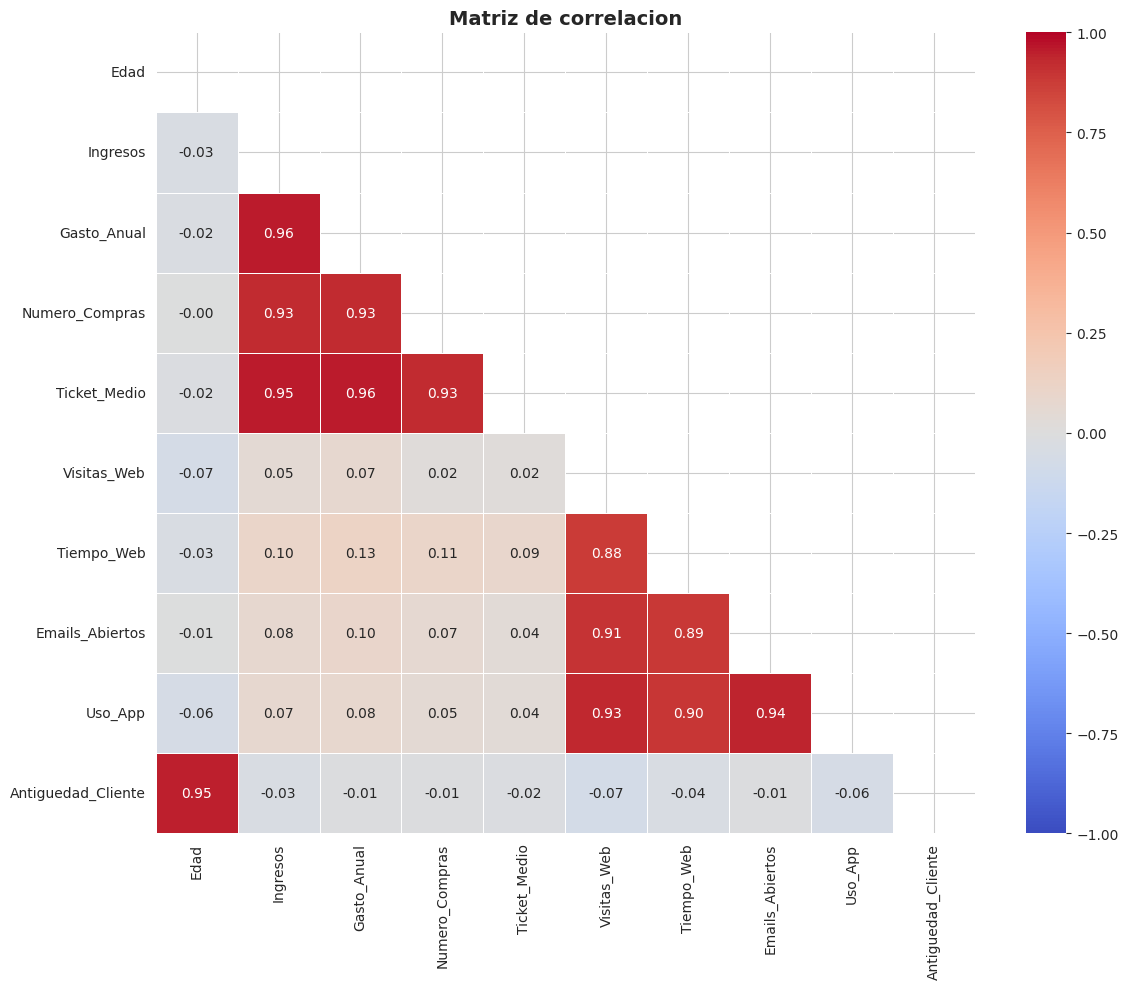


Pares con |r| > 0.6: 13
  Edad - Antiguedad_Cliente: 0.948
  Ingresos - Gasto_Anual: 0.956
  Ingresos - Numero_Compras: 0.926
  Ingresos - Ticket_Medio: 0.953
  Gasto_Anual - Numero_Compras: 0.929
  Gasto_Anual - Ticket_Medio: 0.958
  Numero_Compras - Ticket_Medio: 0.927
  Visitas_Web - Tiempo_Web: 0.875
  Visitas_Web - Emails_Abiertos: 0.905
  Visitas_Web - Uso_App: 0.933
  Tiempo_Web - Emails_Abiertos: 0.886
  Tiempo_Web - Uso_App: 0.898
  Emails_Abiertos - Uso_App: 0.941


In [3]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Variables numericas: {len(num_cols)}")

fig, ax = plt.subplots(figsize=(12, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Matriz de correlacion", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

high_corr = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.6:
            high_corr.append((corr.index[i], corr.columns[j], corr.iloc[i, j]))
print(f"\nPares con |r| > 0.6: {len(high_corr)}")
for v1, v2, r in high_corr:
    print(f"  {v1} - {v2}: {r:.3f}")

## 3. Estandarizacion y PCA

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_cols])

pca = PCA(random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

print("Varianza explicada por componente:")
for i, (v, vc) in enumerate(zip(var_exp, var_cum)):
    bar = "#" * int(v * 50)
    print(f"  PC{i+1}: {v*100:5.1f}% (acum: {vc*100:5.1f}%)  {bar}")

Varianza explicada por componente:
  PC1:  40.6% (acum:  40.6%)  ####################
  PC2:  35.0% (acum:  75.6%)  #################
  PC3:  19.4% (acum:  95.0%)  #########
  PC4:   1.4% (acum:  96.3%)  
  PC5:   1.1% (acum:  97.4%)  
  PC6:   0.7% (acum:  98.1%)  
  PC7:   0.6% (acum:  98.7%)  
  PC8:   0.5% (acum:  99.2%)  
  PC9:   0.4% (acum:  99.7%)  
  PC10:   0.3% (acum: 100.0%)  


## 4. Scree plot

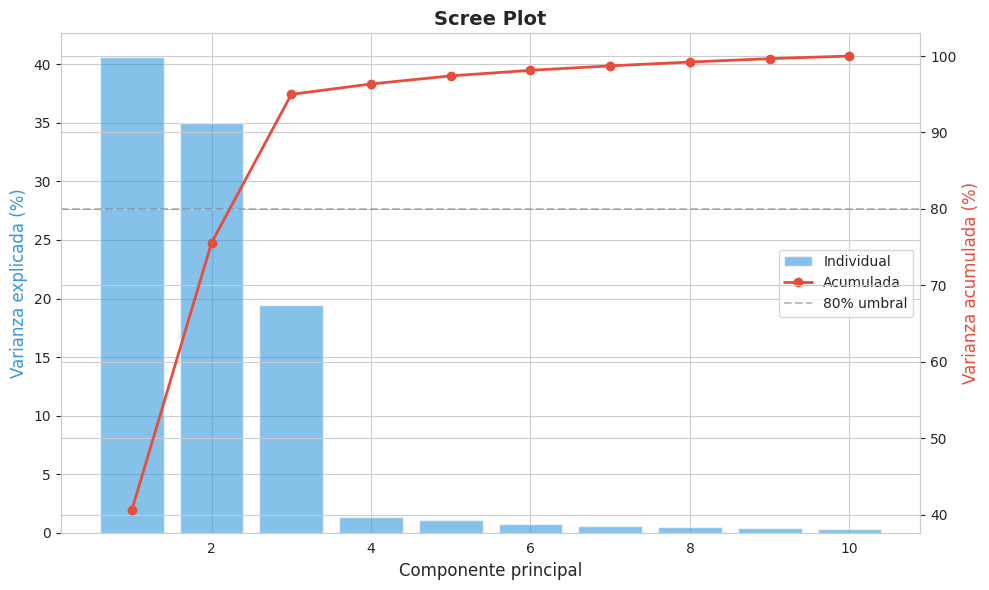

Componentes para >= 80% varianza: 3 de 10


In [5]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(range(1, len(var_exp)+1), var_exp * 100, alpha=0.6, color="#3498db", label="Individual")
ax2 = ax1.twinx()
ax2.plot(range(1, len(var_exp)+1), var_cum * 100, marker="o", color="#e74c3c",
         linewidth=2, label="Acumulada")
ax2.axhline(y=80, color="gray", linestyle="--", alpha=0.5, label="80% umbral")

ax1.set_xlabel("Componente principal", fontsize=12)
ax1.set_ylabel("Varianza explicada (%)", fontsize=12, color="#3498db")
ax2.set_ylabel("Varianza acumulada (%)", fontsize=12, color="#e74c3c")
ax1.set_title("Scree Plot", fontsize=14, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
plt.tight_layout()
plt.show()

n_comp_80 = np.argmax(var_cum >= 0.80) + 1
print(f"Componentes para >= 80% varianza: {n_comp_80} de {len(num_cols)}")

## 5. Loadings heatmap

Los loadings muestran cuanto contribuye cada variable original a cada componente. Valores altos (positivos o negativos) indican variables influyentes.

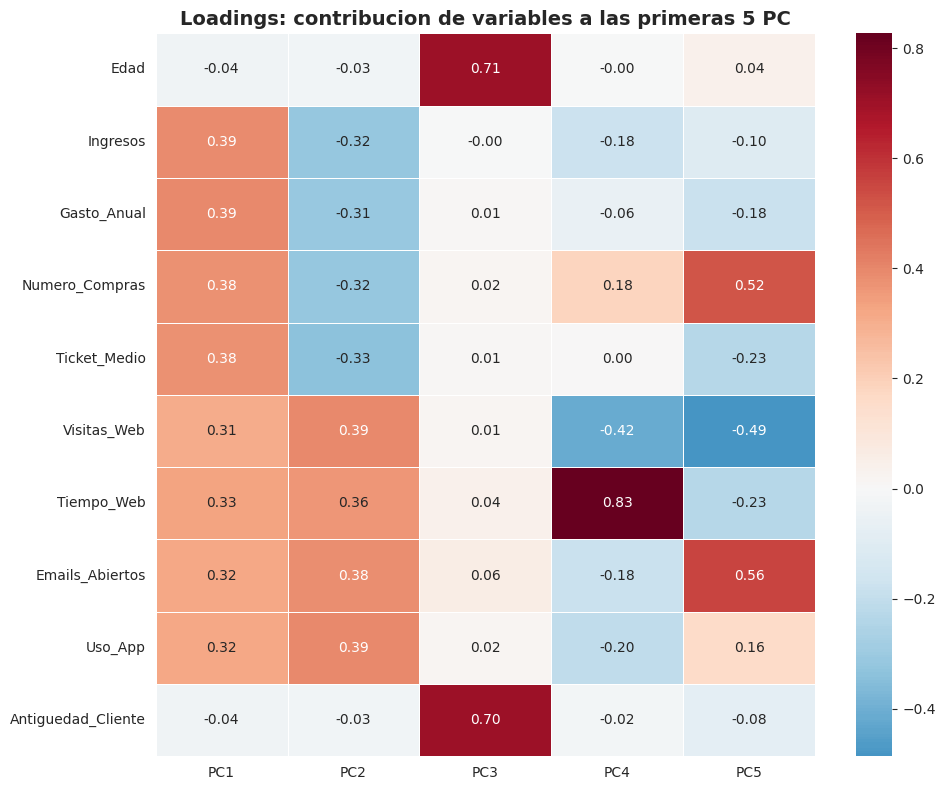

PC1 dominada por: Gasto_Anual, Ingresos, Ticket_Medio
PC2 dominada por: Visitas_Web, Uso_App, Emails_Abiertos
PC3 dominada por: Edad, Antiguedad_Cliente, Emails_Abiertos


In [6]:
n_show = min(5, len(var_exp))
loadings = pd.DataFrame(
    pca.components_[:n_show].T,
    index=num_cols,
    columns=[f"PC{i+1}" for i in range(n_show)]
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=ax)
ax.set_title(f"Loadings: contribucion de variables a las primeras {n_show} PC",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

for pc in loadings.columns[:3]:
    top = loadings[pc].abs().sort_values(ascending=False).head(3)
    print(f"{pc} dominada por: {', '.join(top.index)}")

## 6. Biplot: observaciones + loadings en PC1-PC2

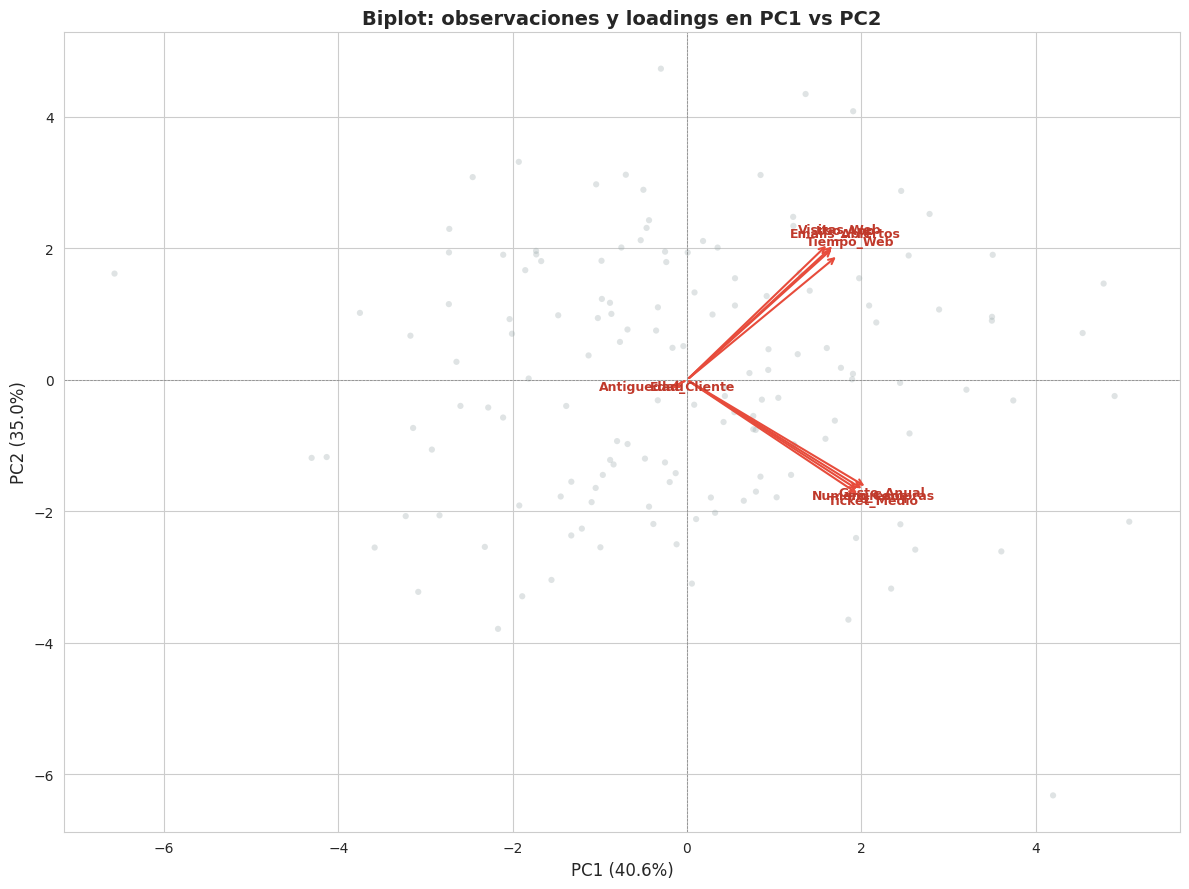

In [7]:
fig, ax = plt.subplots(figsize=(12, 9))

ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=20, color="#95a5a6", edgecolors="none")

scale = max(abs(X_pca[:, 0]).max(), abs(X_pca[:, 1]).max()) * 0.8
for i, var in enumerate(num_cols):
    ax.annotate("", xy=(pca.components_[0, i] * scale, pca.components_[1, i] * scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="#e74c3c", lw=1.5))
    ax.text(pca.components_[0, i] * scale * 1.08, pca.components_[1, i] * scale * 1.08,
            var, fontsize=9, color="#c0392b", ha="center", fontweight="bold")

ax.axhline(y=0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(x=0, color="gray", linewidth=0.5, linestyle="--")
ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)", fontsize=12)
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)", fontsize=12)
ax.set_title("Biplot: observaciones y loadings en PC1 vs PC2", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Proyeccion de clientes en PC1-PC2

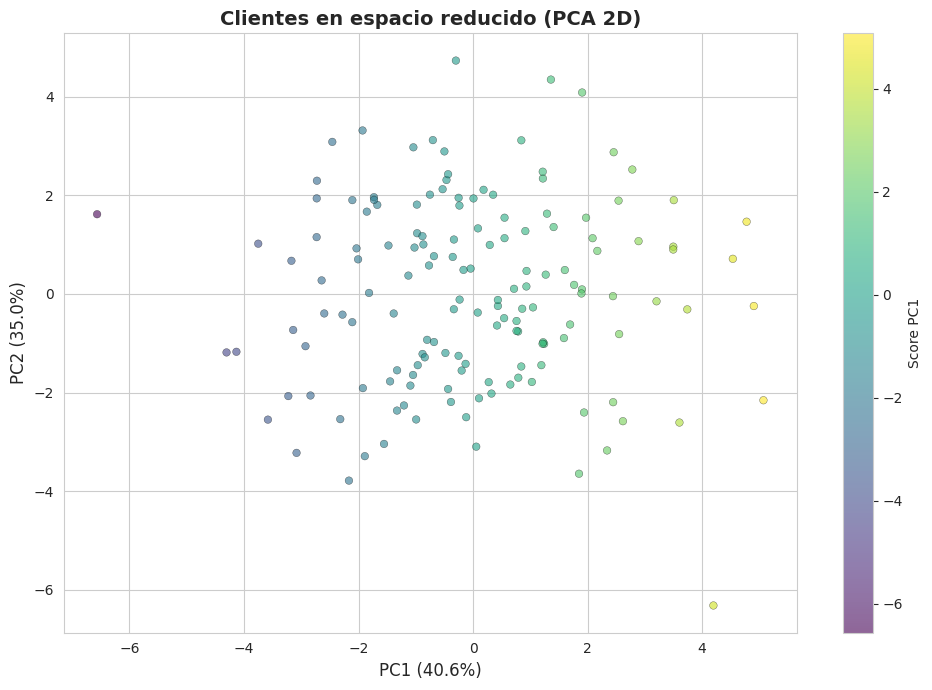

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=X_pca[:, 0], cmap="viridis",
                     alpha=0.6, s=30, edgecolors="k", linewidths=0.3)
plt.colorbar(scatter, ax=ax, label="Score PC1")
ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)", fontsize=12)
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)", fontsize=12)
ax.set_title("Clientes en espacio reducido (PCA 2D)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Conclusiones y recomendaciones

**Hallazgos:**
- PCA reduce las 10 variables originales a unas pocas componentes manteniendo al menos el 80% de la informacion.
- Los loadings revelan dimensiones latentes (ej. "valor del cliente" o "engagement digital") que subyacen a las metricas individuales.
- El biplot permite ver que variables "tiran" en la misma direccion — senal de redundancia que PCA elimina.

**Recomendaciones para el e-commerce:**
- Sustituir las 10 metricas por las primeras componentes principales en dashboards para reducir ruido.
- Usar los scores PCA como input para clustering (K-Means sobre PC1-PC3 en vez de las 10 variables originales).
- Las variables con loadings bajos en todas las PC aportan poca informacion — candidatas a eliminar.

**Limitaciones:**
- PCA es lineal — relaciones no lineales no se capturan (alternativa: t-SNE, UMAP para visualizacion).
- Las componentes son combinaciones de todas las variables, lo que dificulta la interpretacion directa.
- El analisis es descriptivo: no hay variable objetivo ni prediccion.